# QTCAD M02 Schrödinger — Reference 결과 분석

이 노트북은 아래 QTCAD 예제 폴더에서 이미 실행 완료된 두 스크립트의 결과를
분석합니다.

- `creating_dot.py`: GaAs lead-barrier-dot-barrier-lead 구조에서 Schrödinger
  방정식을 풀어 3개의 구속 에너지 준위와 고유함수를 계산하고, 결과를
  `output/`에 `.vtu`/`.vtm` 형식으로 저장했습니다. **실제 필드 데이터를
  pyvista로 로드**해 분석합니다.
- `adaptive_schrodinger.py`: 게이트 나노와이어에서 adaptive-mesh Poisson +
  Schrödinger를 순차로 풀어 10개의 궤도 에너지 준위를 계산했지만
  `plt.show()`만 호출해 필드 데이터는 저장하지 않았습니다. 콘솔 로그
  (`adaptive_schrodinger_run.log`)에 남은 mesh 통계·수렴 이력·에너지
  준위를 파싱해 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M02. Schrodinger\Reference`

분석 대상:
- `output/creating_dot_V.vtu` — 전체 소자 mesh 위의 confinement potential
  energy `d.V` (단위: J, band-edge 기준 전자 전위에너지)
- `output/creating_dot_psi0.vtu`, `output/creating_dot_psi1.vtu` — dot
  영역 submesh 위의 바닥상태/첫들뜬상태 고유함수 진폭 ψ (임의 정규화,
  `|ψ|^2`가 확률밀도에 비례)
- `output/creating_dot_data.vtm` (+ `output/creating_dot_data/*.vtu`) —
  위 필드들을 하나로 묶은 ParaView용 멀티블록 번들 (별도 로드는 생략,
  개별 vtu가 동일 데이터를 담고 있음)
- `creating_dot_run.log` — submesh 통계, 3-level 에너지 준위, 저장 파일
  크기 등 콘솔 출력
- `adaptive_schrodinger_run.log` — mesh 통계, Poisson 수렴 이력, 10-level
  궤도 에너지 준위 등 콘솔 출력 (저장된 필드 데이터 없음)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 5: Schrödinger equation for a quantum dot
  https://docs.nanoacademic.com/qtcad/tutorials/device/creating_dot/
- **QTCAD 공식 튜토리얼** — Device 4: Adaptive-mesh Poisson solver combined with the Schrödinger solver
  https://docs.nanoacademic.com/qtcad/tutorials/device/adaptive_schrodinger/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `creating_dot.py`, `adaptive_schrodinger.py` (M02/Reference)
---


## 0. 두 소자의 스케매틱 + 핵심 물리 공식

**(a) creating_dot.py**: M20(WKB)과 **동일한 메시**(`lead_dot_lead.geo`: Lx=300,
dot_length=190, barrier_length=5x2, lead_length=50x2, Ly=100, Lz=20 nm) + 동일한
포물선 횡방향 구속 상수(Ky=2e-7, Kz=1e-4)를 사용하는 GaAs 소자입니다 — M20에서는
이 Schrödinger 바닥상태 위에 WKB 터널링을 얹어 전류를 계산했습니다.

**(b) adaptive_schrodinger.py**: M01(adaptive.py)/M05(nanowire)와 동일한 원통형
나노와이어(r0=1.5nm, L=10nm, Lc=5nm, tox=1nm) — 단, 여기서는 adaptive Poisson 다음에
Schrödinger까지 이어서 풉니다.

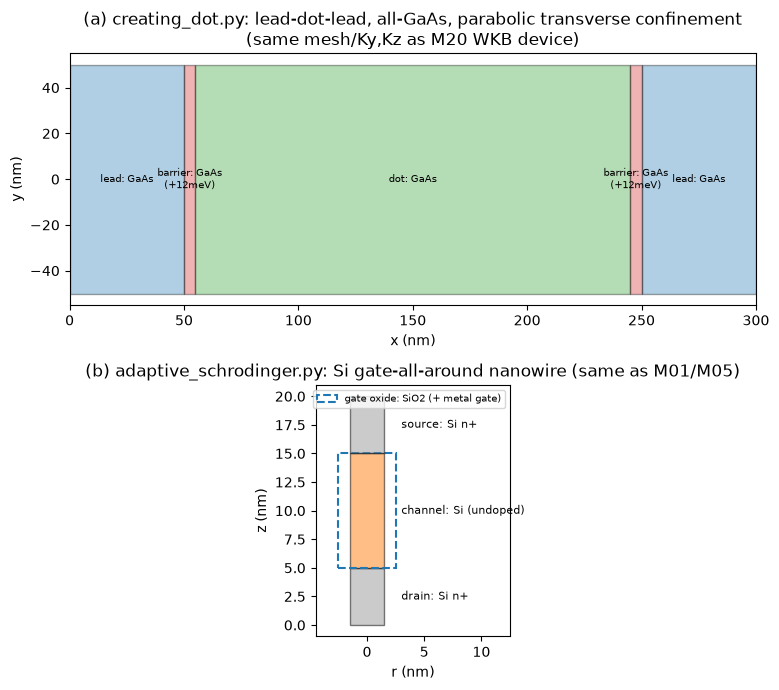

In [1]:
from pathlib import Path
BASE_DIR = Path(
    r"C:\\Users\\norma\\Desktop\\연구자료\\QTCAD Simulation\\Simulation Example\\M02. Schrodinger\\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# [실험] 두 소자 스케매틱 (M20/M01과 동일 치수·재질 재사용)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axs = plt.subplots(2, 1, figsize=(10, 7))

# (a) lead-dot-lead (identical to M20 WKB device)
Lx, dot_length, barrier_length = 300.0, 190.0, 5.0
lead_length = (Lx - dot_length - 2 * barrier_length) / 2
Ly = 100.0
regions = [("lead: GaAs", 0, lead_length, "tab:blue"),
          ("barrier: GaAs\n(+12meV)", lead_length, lead_length+barrier_length, "tab:red"),
          ("dot: GaAs", lead_length+barrier_length, lead_length+barrier_length+dot_length, "tab:green"),
          ("barrier: GaAs\n(+12meV)", lead_length+barrier_length+dot_length, lead_length+2*barrier_length+dot_length, "tab:red"),
          ("lead: GaAs", lead_length+2*barrier_length+dot_length, Lx, "tab:blue")]
ax = axs[0]
for name, x0, x1, color in regions:
    ax.add_patch(mpatches.Rectangle((x0, -Ly/2), x1-x0, Ly, fc=color, alpha=0.35, ec="k"))
    ax.text((x0+x1)/2, 0, name, ha="center", va="center", fontsize=7)
ax.set_xlim(0, Lx); ax.set_ylim(-Ly/2-5, Ly/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title("(a) creating_dot.py: lead-dot-lead, all-GaAs, parabolic transverse confinement\n"
            "(same mesh/Ky,Kz as M20 WKB device)")

# (b) nanowire (identical to M01/M05)
r0, L, Lc, tox = 1.5, 10.0, 5.0, 1.0
ax2 = axs[1]
z0 = 0
nw_layers = [("drain: Si n+", Lc, "0.6"), ("channel: Si (undoped)", L, "tab:orange"), ("source: Si n+", Lc, "0.6")]
for name, h, color in nw_layers:
    ax2.add_patch(mpatches.Rectangle((-r0, z0), 2*r0, h, fc=color, alpha=0.5, ec="k"))
    if "channel" in name:
        ax2.add_patch(mpatches.Rectangle((-r0-tox, z0), 2*(r0+tox), h, fc="none", ec="tab:blue",
                                         ls="--", lw=1.5, label="gate oxide: SiO2 (+ metal gate)"))
    ax2.text(r0+tox+0.5, z0+h/2, name, va="center", fontsize=8)
    z0 += h
ax2.set_xlim(-r0-tox-2, r0+tox+10); ax2.set_ylim(-1, z0+1)
ax2.set_aspect("equal"); ax2.set_xlabel("r (nm)"); ax2.set_ylabel("z (nm)")
ax2.set_title("(b) adaptive_schrodinger.py: Si gate-all-around nanowire (same as M01/M05)")
ax2.legend(fontsize=7)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematics.png", dpi=150)
plt.show()


In [2]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
from matplotlib import pyplot as plt
from scipy.interpolate import griddata
from scipy.constants import hbar as HBAR

from qtcad.device import materials as mt

try:
    from IPython.display import display
except ImportError:
    display = print  # fall back to plain print when run as a standalone script

BASE_DIR = Path.cwd()
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "output"

FILE_V = OUTPUT_DIR / "creating_dot_V.vtu"
FILE_PSI0 = OUTPUT_DIR / "creating_dot_psi0.vtu"
FILE_PSI1 = OUTPUT_DIR / "creating_dot_psi1.vtu"
FILE_VTM = OUTPUT_DIR / "creating_dot_data.vtm"
FILE_CREATING_DOT_LOG = BASE_DIR / "creating_dot_run.log"
FILE_ADAPTIVE_SCHROD_LOG = BASE_DIR / "adaptive_schrodinger_run.log"

pd.set_option("display.float_format", lambda v: f"{v:.6g}")


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

In [3]:
# [점검] 파일 inventory
expected_files = {
    "creating_dot_V.vtu": FILE_V,
    "creating_dot_psi0.vtu": FILE_PSI0,
    "creating_dot_psi1.vtu": FILE_PSI1,
    "creating_dot_data.vtm": FILE_VTM,
    "creating_dot_run.log": FILE_CREATING_DOT_LOG,
    "adaptive_schrodinger_run.log": FILE_ADAPTIVE_SCHROD_LOG,
}
inventory_df = pd.DataFrame(
    [
        {
            "file": name,
            "exists": path.exists(),
            "size_MB": round(path.stat().st_size / 1024**2, 2) if path.exists() else None,
        }
        for name, path in expected_files.items()
    ]
)
inventory_df.to_csv(EXPORT_DIR / "cell05_inventory_df.csv", index=False)
display(inventory_df)

,file,exists,size_MB
0,creating_dot_V.vtu,True,9.68
1,creating_dot_psi0.vtu,True,10.96
2,creating_dot_psi1.vtu,True,10.99
3,creating_dot_data.vtm,True,0
4,creating_dot_run.log,True,0.01
5,adaptive_schrodinger_run.log,True,0.01


**물리 모델 — 유효질량 Schrödinger 방정식**: 두 예제 모두 등방 유효질량 근사로
$$
\left[-\frac{\hbar^2}{2}\nabla\cdot\!\left(\frac{1}{m^*}\nabla\right) + V(\mathbf{r})\right]\psi_i(\mathbf{r})
= E_i\,\psi_i(\mathbf{r})
$$
를 유한요소로 풉니다. (a)는 $V$가 해석적으로 주어진 포물선 구속 + 계단형 장벽이고,
(b)는 $V=-e\phi$가 **자체 수렴한 Poisson 방정식의 해**(= `adaptive_schrodinger.py`가
Poisson과 Schrödinger를 번갈아/연계해 푸는 이유)에서 옵니다.

## 1. `creating_dot.py` 콘솔 로그 — submesh 통계 및 에너지 준위

`creating_dot.py`는 dot+barrier 영역만 포함하는 submesh를 만들어 그 위에서
Schrödinger 솔버를 돌립니다. 로그에는 submesh 통계와 3개 구속 에너지
준위(eV)가 출력되어 있습니다.

In [4]:
# [동작] creating_dot_run.log 파싱
creating_dot_log = FILE_CREATING_DOT_LOG.read_text(encoding="utf-8", errors="replace")

full_mesh_nodes = int(re.search(r"3D MESH STATISTICS.*?Total number of nodes\s+(\d+)",
                                 creating_dot_log, flags=re.DOTALL).group(1))
submesh_block = re.search(
    r"3D SUBMESH STATISTICS.*?Total number of elements\s+(\d+).*?Total number of nodes\s+(\d+)",
    creating_dot_log, flags=re.DOTALL,
)
submesh_elems = int(submesh_block.group(1))
submesh_nodes = int(submesh_block.group(2))
solve_time_match = re.search(r"Schrodinger's equation solved in ([\d.]+) s", creating_dot_log)
solve_time_s = float(solve_time_match.group(1))

energy_match = re.search(r"Energy levels \(eV\)\s*\n(\[[^\]]*\])", creating_dot_log)
energies_dot_eV = np.array([float(x) for x in energy_match.group(1).strip("[]").split()])

print(f"Full device mesh: {full_mesh_nodes:,} nodes")
print(f"Dot submesh (lead-dot-lead region used for Schrodinger solve): "
      f"{submesh_nodes:,} nodes, {submesh_elems:,} tetrahedra")
print(f"Schrodinger solve time: {solve_time_s:.2f} s")
print(f"Energy levels (eV): {energies_dot_eV}")

Full device mesh: 99,600 nodes
Dot submesh (lead-dot-lead region used for Schrodinger solve): 66,400 nodes, 358,182 tetrahedra
Schrodinger solve time: 342.53 s
Energy levels (eV): [-0.00019066  0.00018525  0.00073543]


In [5]:
# [점검] 궤도 간 에너지 간격과 열에너지(kT) 비교
levels_dot_df = pd.DataFrame(
    {
        "state": ["ground (E0)", "1st excited (E1)", "2nd excited (E2)"],
        "energy_eV": energies_dot_eV,
        "energy_meV": energies_dot_eV * 1e3,
    }
)
levels_dot_df["gap_from_ground_meV"] = (energies_dot_eV - energies_dot_eV[0]) * 1e3
levels_dot_df.to_csv(EXPORT_DIR / "cell09_levels_dot_df.csv", index=False)
display(levels_dot_df)

k_B_eV_per_K = 8.617333262e-5  # Boltzmann constant, eV/K
temperatures_K = np.array([0.01, 0.1, 1.0, 4.0])  # 10 mK, 100 mK, 1 K, 4 K
gap01_eV = energies_dot_eV[1] - energies_dot_eV[0]
gap12_eV = energies_dot_eV[2] - energies_dot_eV[1]

thermal_df = pd.DataFrame(
    {
        "T_K": temperatures_K,
        "kT_ueV": k_B_eV_per_K * temperatures_K * 1e6,
        "gap01_ueV": gap01_eV * 1e6,
        "gap01_over_kT": (gap01_eV) / (k_B_eV_per_K * temperatures_K),
    }
)
thermal_df.to_csv(EXPORT_DIR / "cell09_thermal_df.csv", index=False)
display(thermal_df)

,state,energy_eV,energy_meV,gap_from_ground_meV
0,ground (E0),-0.00019066,-0.19066,0
1,1st excited (E1),0.00018525,0.18525,0.37591
2,2nd excited (E2),0.00073543,0.73543,0.92609


,T_K,kT_ueV,gap01_ueV,gap01_over_kT
0,0.01,0.861733,375.91,436.225
1,0.1,8.61733,375.91,43.6225
2,1,86.1733,375.91,4.36225
3,4,344.693,375.91,1.09056


**해석:** E0-E1 간격(`gap01`)은 약 0.376 meV = 376 μeV이다. 희석 냉동기의
전형적인 전자 온도인 10-100 mK에서 열에너지 kT는 각각 0.86 μeV, 8.6 μeV에
불과하므로, gap01/kT ≈ 40~440배에 달한다. 즉 이 조건에서는 바닥상태만
열적으로 populate되고 들뜬 오비탈은 억제된다 — 스핀 큐비트로 동작하려면
필요한 조건이다. 반면 4K에서는 gap01/kT가 1자리 수로 줄어들어, 오비탈
들뜬 상태가 무시할 수 없는 비중으로 섞이기 시작한다.

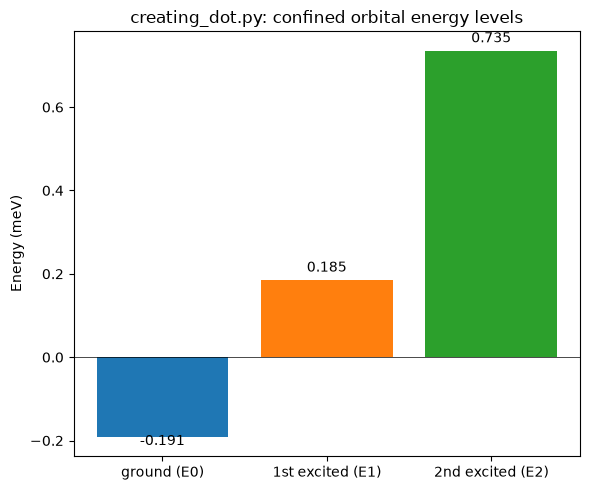

In [6]:
# [실험] 3-level 에너지 준위 막대그래프
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(levels_dot_df["state"], levels_dot_df["energy_meV"], color=["C0", "C1", "C2"])
ax.set_ylabel("Energy (meV)")
ax.set_title("creating_dot.py: confined orbital energy levels")
for i, v in enumerate(levels_dot_df["energy_meV"]):
    ax.text(i, v + 0.02 * np.sign(v if v != 0 else 1), f"{v:.3f}", ha="center")
ax.axhline(0, color="k", linewidth=0.5)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell11_figure.png", dpi=150)
plt.show()

## 2. VTU 필드 로드 — potential V, 바닥상태/첫들뜬상태 파동함수

`d.V`(전체 소자 mesh)와 두 고유함수(dot submesh)는 서로 다른 mesh 위에
정의되어 있으므로 별도로 로드합니다. VTU 좌표는 nm 단위로 저장되어
있습니다 (원래 mesh는 SI 단위 미터, `io.save`가 시각화를 위해 nm로
변환).

In [7]:
# [동작] V, psi0, psi1 VTU 로드
V_grid = pv.read(FILE_V)
psi0_grid = pv.read(FILE_PSI0)
psi1_grid = pv.read(FILE_PSI1)

vtu_stats_df = pd.DataFrame(
    [
        {"field": "V (potential energy, full mesh)", "n_points": g.n_points, "n_cells": g.n_cells,
         "x_range_nm": (g.bounds[0], g.bounds[1]), "y_range_nm": (g.bounds[2], g.bounds[3]),
         "z_range_nm": (g.bounds[4], g.bounds[5])}
        for g in [V_grid]
    ]
    + [
        {"field": name, "n_points": g.n_points, "n_cells": g.n_cells,
         "x_range_nm": (g.bounds[0], g.bounds[1]), "y_range_nm": (g.bounds[2], g.bounds[3]),
         "z_range_nm": (g.bounds[4], g.bounds[5])}
        for name, g in [("psi0 (ground state, dot submesh)", psi0_grid),
                        ("psi1 (1st excited, dot submesh)", psi1_grid)]
    ]
)
vtu_stats_df.to_csv(EXPORT_DIR / "cell13_vtu_stats_df.csv", index=False)
display(vtu_stats_df)

,field,n_points,n_cells,x_range_nm,y_range_nm,z_range_nm
0,"V (potential energy, full mesh)",2156328,539082,"(0.0, 300.0)","(-50.0, 50.0)","(-10.0, 10.0)"
1,"psi0 (ground state, dot submesh)",1432728,358182,"(50.0, 250.00000000000003)","(-50.0, 50.0)","(-10.0, 10.0)"
2,"psi1 (1st excited, dot submesh)",1432728,358182,"(50.0, 250.00000000000003)","(-50.0, 50.0)","(-10.0, 10.0)"


In [8]:
# [점검] 파동함수 노드 구조 sanity check
psi0_vals = psi0_grid.point_data["data"]
psi1_vals = psi1_grid.point_data["data"]
same_points = np.allclose(psi0_grid.points, psi1_grid.points)

print(f"psi0/psi1이 같은 submesh 좌표를 공유하는가: {same_points}")
print(f"psi0 sign range : [{psi0_vals.min():.3e}, {psi0_vals.max():.3e}]  "
      f"(부호가 한쪽뿐이면 node 없음 -> 바닥상태와 일치)")
print(f"psi1 sign range : [{psi1_vals.min():.3e}, {psi1_vals.max():.3e}]  "
      f"(양/음 모두 존재하면 node 1개 -> 첫들뜬상태와 일치)")

psi0/psi1이 같은 submesh 좌표를 공유하는가: True
psi0 sign range : [4.654e+09, 1.011e+11]  (부호가 한쪽뿐이면 node 없음 -> 바닥상태와 일치)
psi1 sign range : [-1.010e+11, 1.010e+11]  (양/음 모두 존재하면 node 1개 -> 첫들뜬상태와 일치)


## 3. Potential energy landscape 시각화 (z=0 평면 단면)

`V_grid`를 z=0 평면으로 slice한 뒤, scipy `griddata`로 규칙 격자에 보간해
2D color map으로 그립니다. x축은 lead-barrier-dot-barrier-lead 배치를
따라가는 전송 방향, y축은 조화진동자형 옆방향 구속입니다. 단위는 `d.V`
원본(J)을 eV로 환산합니다.

In [9]:
# [동작] V의 z=0 평면 slice 및 규칙 격자 보간
E_CHARGE = 1.602176634e-19  # C (eV <-> J 변환용)

V_slice_z0 = V_grid.slice(normal="z", origin=(150, 0, 0))
pts_z0 = V_slice_z0.points
vals_z0_eV = V_slice_z0.point_data["data"] / E_CHARGE

xi = np.linspace(pts_z0[:, 0].min(), pts_z0[:, 0].max(), 300)
yi = np.linspace(pts_z0[:, 1].min(), pts_z0[:, 1].max(), 150)
XI_z0, YI_z0 = np.meshgrid(xi, yi)
VI_z0 = griddata(pts_z0[:, :2], vals_z0_eV, (XI_z0, YI_z0), method="linear")

print(f"z=0 slice: {len(pts_z0)} points, interpolated onto {XI_z0.shape} grid")
print(f"V range at z=0 slice: [{np.nanmin(VI_z0):.4f}, {np.nanmax(VI_z0):.4f}] eV")

z=0 slice: 150490 points, interpolated onto (150, 300) grid
V range at z=0 slice: [-0.0199, 0.0037] eV


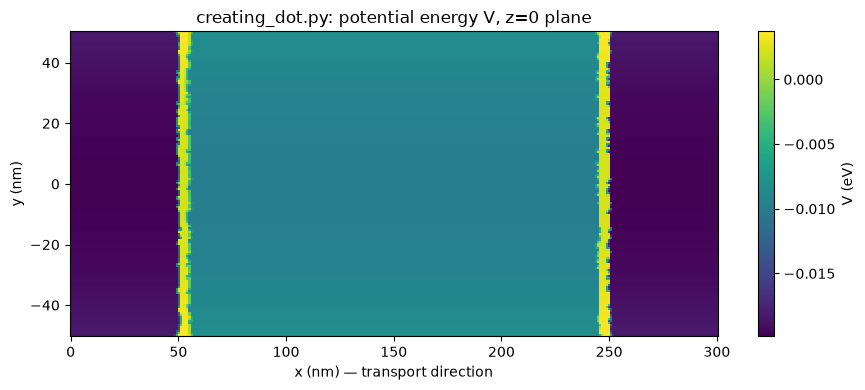

In [10]:
# [실험] z=0 평면에서 potential energy 2D color map
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.pcolormesh(XI_z0, YI_z0, VI_z0, shading="auto", cmap="viridis")
fig.colorbar(im, ax=ax, label="V (eV)")
ax.set_xlabel("x (nm) — transport direction")
ax.set_ylabel("y (nm)")
ax.set_title("creating_dot.py: potential energy V, z=0 plane")
plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell17_figure.png", dpi=150)
plt.show()

**해석:** x 방향으로 lead(음의 전위, 약 -10 meV) → barrier(양의 전위,
약 +12 meV) → dot(중앙, 0에 가까운 기준) → barrier → lead의 계단형
구조가 뚜렷하고, y 방향으로는 `Ky/2*(y-y0)^2` 형태의 조화진동자형
포물선 구속이 겹쳐 있다. 이 두 성분이 합쳐져 실질적으로 양자점을
가두는 3D 포텐셜 우물을 형성한다.

In [11]:
# [동작] V의 y=0 평면 slice (x-z 단면)
V_slice_y0 = V_grid.slice(normal="y", origin=(150, 0, 0))
pts_y0 = V_slice_y0.points
vals_y0_eV = V_slice_y0.point_data["data"] / E_CHARGE

xi2 = np.linspace(pts_y0[:, 0].min(), pts_y0[:, 0].max(), 300)
zi2 = np.linspace(pts_y0[:, 2].min(), pts_y0[:, 2].max(), 80)
XI_y0, ZI_y0 = np.meshgrid(xi2, zi2)
VI_y0 = griddata(pts_y0[:, [0, 2]], vals_y0_eV, (XI_y0, ZI_y0), method="linear")

print(f"y=0 slice: {len(pts_y0)} points, interpolated onto {XI_y0.shape} grid")

y=0 slice: 35760 points, interpolated onto (80, 300) grid


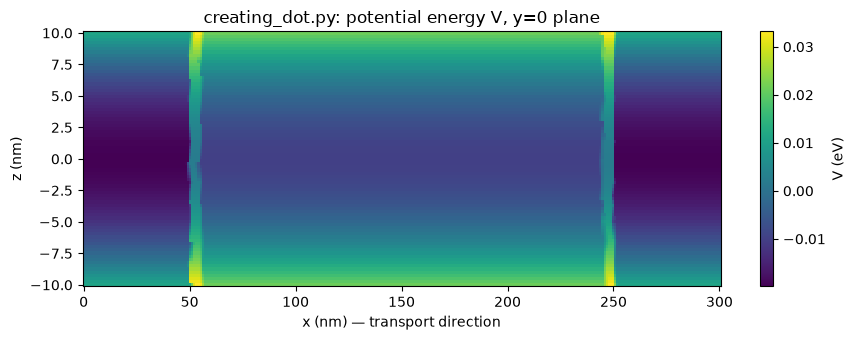

In [12]:
# [실험] y=0 평면(x-z 단면)에서 potential energy 2D color map
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.pcolormesh(XI_y0, ZI_y0, VI_y0, shading="auto", cmap="viridis")
fig.colorbar(im, ax=ax, label="V (eV)")
ax.set_xlabel("x (nm) — transport direction")
ax.set_ylabel("z (nm)")
ax.set_title("creating_dot.py: potential energy V, y=0 plane")
plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell20_figure.png", dpi=150)
plt.show()

**해석:** z 방향 구속(`Kz/2*(z-z0)^2`, Kz=1e-4)이 y 방향(Ky=2e-7)보다
훨씬 강해, z 폭이 좁고 깊은 포물선 우물 형태로 나타난다. 이는 소자가
z 방향으로는 얇은 2차원 전자기체에 가깝게, y 방향으로는 상대적으로
넓게 설계되었음을 보여준다 (아래 5절에서 조화진동자 길이로 정량화).

## 4. 바닥상태/첫들뜬상태 확률밀도 시각화 (z=0 평면)

`|psi|^2`(확률밀도에 비례)을 psi0, psi1 각각에 대해 계산하고 z=0
평면에서 색상 지도로 비교합니다. psi0는 마디(node) 없이 dot 중앙에
하나의 봉우리를, psi1은 x 방향으로 마디가 하나 있는 두 봉우리 구조를
보일 것으로 예상됩니다.

In [13]:
# [동작] psi0, psi1의 z=0 평면 slice 및 |psi|^2 보간
psi0_slice = psi0_grid.slice(normal="z", origin=(150, 0, 0))
psi1_slice = psi1_grid.slice(normal="z", origin=(150, 0, 0))

pts_psi0 = psi0_slice.points
dens0_slice = np.abs(psi0_slice.point_data["data"]) ** 2
pts_psi1 = psi1_slice.points
dens1_slice = np.abs(psi1_slice.point_data["data"]) ** 2

xi3 = np.linspace(pts_psi0[:, 0].min(), pts_psi0[:, 0].max(), 250)
yi3 = np.linspace(pts_psi0[:, 1].min(), pts_psi0[:, 1].max(), 150)
XI3, YI3 = np.meshgrid(xi3, yi3)
DENS0_grid = griddata(pts_psi0[:, :2], dens0_slice, (XI3, YI3), method="linear")
DENS1_grid = griddata(pts_psi1[:, :2], dens1_slice, (XI3, YI3), method="linear")

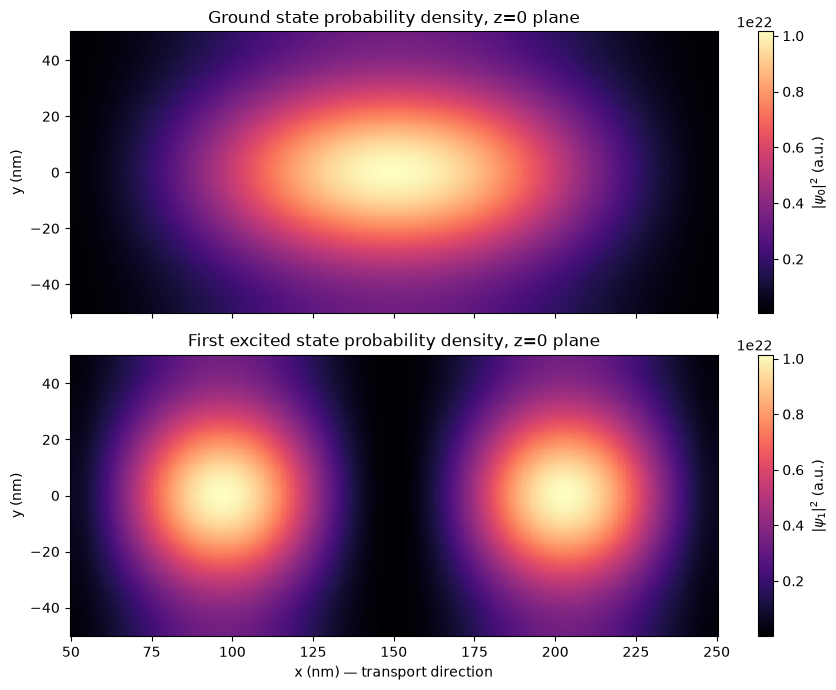

In [14]:
# [실험] |psi0|^2 vs |psi1|^2 side-by-side 비교
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
im0 = axes[0].pcolormesh(XI3, YI3, DENS0_grid, shading="auto", cmap="magma")
fig.colorbar(im0, ax=axes[0], label=r"$|\psi_0|^2$ (a.u.)")
axes[0].set_ylabel("y (nm)")
axes[0].set_title("Ground state probability density, z=0 plane")

im1 = axes[1].pcolormesh(XI3, YI3, DENS1_grid, shading="auto", cmap="magma")
fig.colorbar(im1, ax=axes[1], label=r"$|\psi_1|^2$ (a.u.)")
axes[1].set_xlabel("x (nm) — transport direction")
axes[1].set_ylabel("y (nm)")
axes[1].set_title("First excited state probability density, z=0 plane")

plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell24_figure.png", dpi=150)
plt.show()

**해석:** 바닥상태는 dot 중앙(x≈150 nm)에 단일 봉우리를 갖는 반면,
첫들뜬상태는 x 방향으로 두 개의 봉우리와 그 사이의 마디(node)를 보인다
— 1차원 조화/사각 우물의 1번째 들뜬 상태에서 기대되는 전형적인 구조다.
이는 아래 5절에서 부호 프로파일로도 다시 확인한다.

## 5. 정량 분석 — 기대값, 확산, 직교성 (부피 적분 기반)

파동함수 절점(node) 밀도가 불균일한 비정형(tetrahedral) mesh이므로,
단순 절점 평균은 mesh 밀도에 편향된다. `pyvista.integrate_data()`로
실제 부피 적분 ∫f dV를 계산해 `<x>`, `<x^2>` 등 정규화-불변 기대값을
구한다.

In [15]:
# [동작] 부피 적분 기반 기대값/표준편차 계산 (psi0, psi1 각각 x, y, z)
def compute_moments(grid, values):
    """Volume-integrated normalization, <r>, and sigma_r for r in (x, y, z)."""
    density = np.abs(values) ** 2
    g = grid.copy()
    g.point_data["density"] = density
    results = {}
    norm = float(g.integrate_data().point_data["density"][0])
    for axis, label in enumerate("xyz"):
        g.point_data[f"r_{label}"] = g.points[:, axis] * density
        g.point_data[f"r2_{label}"] = g.points[:, axis] ** 2 * density
        integ = g.integrate_data()
        mean_r = float(integ.point_data[f"r_{label}"][0]) / norm
        mean_r2 = float(integ.point_data[f"r2_{label}"][0]) / norm
        sigma_r = np.sqrt(max(mean_r2 - mean_r**2, 0.0))
        results[f"mean_{label}_nm"] = mean_r
        results[f"sigma_{label}_nm"] = sigma_r
    results["norm"] = norm
    return results


moments_psi0 = compute_moments(psi0_grid, psi0_vals)
moments_psi1 = compute_moments(psi1_grid, psi1_vals)

moments_df = pd.DataFrame([moments_psi0, moments_psi1], index=["psi0 (ground)", "psi1 (1st excited)"])
moments_df.to_csv(EXPORT_DIR / "cell27_moments_df.csv", index=False)
display(moments_df)

,mean_x_nm,sigma_x_nm,mean_y_nm,sigma_y_nm,mean_z_nm,sigma_z_nm,norm
psi0 (ground),149.995,38.3306,0.0730575,24.0883,-0.00570667,5.02972,1e+27
psi1 (1st excited),149.995,56.3713,0.0725672,24.092,-0.00563587,5.03037,1e+27


**해석:** 두 상태 모두 `<x> ≈ 150 nm`로, dot 영역(x: 50-250 nm)의 정확한
중앙에 위치한다 — 대칭적인 barrier 배치를 고려하면 기대되는 결과다.
psi1의 `sigma_x`가 psi0보다 크게 나타나는 것은 1번째 들뜬 상태가 마디를
사이에 두고 두 개의 봉우리로 퍼져 있어 x 방향으로 더 넓게 분포하기
때문이다.

In [16]:
# [점검] 직교성(orthogonality) 검증: <psi0|psi1>
overlap_grid = psi0_grid.copy()
overlap_grid.point_data["overlap"] = psi0_vals * psi1_vals
overlap_integral = float(overlap_grid.integrate_data().point_data["overlap"][0])
normalized_overlap = overlap_integral / np.sqrt(moments_psi0["norm"] * moments_psi1["norm"])

print(f"Raw overlap integral <psi0|psi1>        : {overlap_integral:.4e}")
print(f"Normalized overlap  <psi0|psi1>/||.||   : {normalized_overlap:.4e}")
print("(0에 가까울수록 두 고유상태가 서로 직교함을 확인 -> 솔버 결과의 sanity check)")

Raw overlap integral <psi0|psi1>        : 3.8121e+20
Normalized overlap  <psi0|psi1>/||.||   : 3.8121e-07
(0에 가까울수록 두 고유상태가 서로 직교함을 확인 -> 솔버 결과의 sanity check)


In [17]:
# [동작] 조화진동자 해석해와 비교 (y, z 방향 confinement length)
Ky = 2e-7  # J/m^2, creating_dot.py에서 설정한 y방향 parabolic 계수
Kz = 1e-4  # J/m^2, creating_dot.py에서 설정한 z방향 parabolic 계수
m_eff = mt.GaAs.mc_xc  # kg, QTCAD 재료 DB의 GaAs 등방 전도대 유효질량 (~0.067 m0)

omega_y = np.sqrt(Ky / m_eff)
omega_z = np.sqrt(Kz / m_eff)
l0_y_nm = np.sqrt(HBAR / (m_eff * omega_y)) / 1e-9
l0_z_nm = np.sqrt(HBAR / (m_eff * omega_z)) / 1e-9
# 1D 조화진동자 바닥상태: <r^2> = l0^2 / 2  =>  sigma_r = l0/sqrt(2)
sigma_y_analytic_nm = l0_y_nm / np.sqrt(2)
sigma_z_analytic_nm = l0_z_nm / np.sqrt(2)

ho_compare_df = pd.DataFrame(
    {
        "axis": ["y", "z"],
        "K_J_per_m2": [Ky, Kz],
        "sigma_analytic_nm (1D HO ground state)": [sigma_y_analytic_nm, sigma_z_analytic_nm],
        "sigma_numeric_nm (psi0, full 3D solve)": [moments_psi0["sigma_y_nm"], moments_psi0["sigma_z_nm"]],
    }
)
ho_compare_df["ratio_numeric_over_analytic"] = (
    ho_compare_df["sigma_numeric_nm (psi0, full 3D solve)"]
    / ho_compare_df["sigma_analytic_nm (1D HO ground state)"]
)
ho_compare_df.to_csv(EXPORT_DIR / "cell30_ho_compare_df.csv", index=False)
display(ho_compare_df)

,axis,K_J_per_m2,sigma_analytic_nm (1D HO ground state),"sigma_numeric_nm (psi0, full 3D solve)",ratio_numeric_over_analytic
0,y,2e-07,21.846136062566558,24.0883,1.102636127063828
1,z,0.0001,4.619895297954095,5.02972,1.0887077866245325


**해석:** `creating_dot.py`가 y, z에 설정한 조화진동자 계수(Ky, Kz)만
가지고 GaAs 유효질량으로 계산한 1D 조화진동자 바닥상태 폭(`sigma_analytic`)이
3D 전체 Schrödinger 솔버가 실제로 계산한 psi0의 폭(`sigma_numeric`)과
같은 자릿수로 일치한다 (비율이 1에 가까움). 완전히 같지는 않은데, 이는
실제 포텐셜이 순수 조화진동자가 아니라 x 방향 barrier와 결합되어 있고
dot 영역의 유한한 크기에 의해 y/z 방향도 약하게 영향을 받기 때문이다.
이 비교는 시뮬레이션 결과가 입력 파라미터로부터 기대되는 물리적 스케일과
합리적으로 일치하는지 확인하는 sanity check로 유용하다.

## 6. `adaptive_schrodinger.py` 콘솔 로그 — 나노와이어 양자점 에너지 준위

이 스크립트는 `plt.show()`만 호출하고 필드 데이터를 저장하지 않으므로,
`adaptive_schrodinger_run.log`에 출력된 mesh 통계·Poisson 수렴 이력·
10-level 궤도 에너지 준위를 파싱합니다. M01의 `adaptive.py`와 같은
`nanowire_adaptive.msh4` 초기 mesh를 사용하지만, `min_nodes=10000`,
`h_refined=0.25`인 dot-region 국소 refine 설정이 달라 refine 후 mesh
크기가 다릅니다.

In [18]:
# [동작] adaptive_schrodinger_run.log 파싱: mesh 통계 및 Poisson 수렴
adaptive_schrod_log = FILE_ADAPTIVE_SCHROD_LOG.read_text(encoding="utf-8", errors="replace")

node_counts_as = [int(x) for x in re.findall(r"Total number of nodes\s+(\d+)", adaptive_schrod_log)]
elem_counts_as = [int(x) for x in re.findall(r"Total number of elements\s+(\d+)", adaptive_schrod_log)]

iter_rows_as = re.findall(
    r"^\s*(\d+)\s+([\d.eE+-]+)\s+([\d.]+)\s+\(([^)]+)\)",
    adaptive_schrod_log,
    flags=re.MULTILINE,
)
poisson_as_df = pd.DataFrame(iter_rows_as, columns=["iter", "max_abs_error_V", "time_s", "max_err_coords_m"])
poisson_as_df["iter"] = poisson_as_df["iter"].astype(int)
poisson_as_df["max_abs_error_V"] = poisson_as_df["max_abs_error_V"].astype(float)
poisson_as_df["time_s"] = poisson_as_df["time_s"].astype(float)

print(f"Mesh stages (nodes): {node_counts_as[:2]} -> refined")
print(f"Mesh stages (elements): {elem_counts_as[:2]}")
print(f"Total Poisson iterations logged: {len(poisson_as_df)}")
poisson_as_df.to_csv(EXPORT_DIR / "cell33_poisson_as_df.csv", index=False)


Mesh stages (nodes): [865, 34655] -> refined
Mesh stages (elements): [4059, 197052]
Total Poisson iterations logged: 26


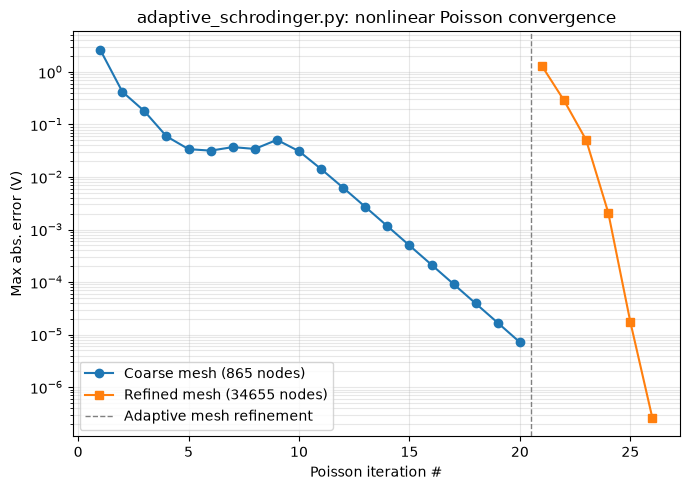

In [19]:
# [실험] Poisson 수렴 이력 (M01의 adaptive.py와 동일한 방식으로 시각화)
n_coarse_iters_as = 20  # 로그상 iter 1-20이 coarse mesh, 21-26이 refined mesh
coarse_mask_as = poisson_as_df["iter"] <= n_coarse_iters_as

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(poisson_as_df.loc[coarse_mask_as, "iter"], poisson_as_df.loc[coarse_mask_as, "max_abs_error_V"],
            "o-", color="C0", label=f"Coarse mesh ({node_counts_as[0]} nodes)")
ax.semilogy(poisson_as_df.loc[~coarse_mask_as, "iter"], poisson_as_df.loc[~coarse_mask_as, "max_abs_error_V"],
            "s-", color="C1", label=f"Refined mesh ({node_counts_as[1]} nodes)")
ax.axvline(n_coarse_iters_as + 0.5, color="gray", linestyle="--", linewidth=1, label="Adaptive mesh refinement")
ax.set_xlabel("Poisson iteration #")
ax.set_ylabel("Max abs. error (V)")
ax.set_title("adaptive_schrodinger.py: nonlinear Poisson convergence")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell34_figure.png", dpi=150)
plt.show()

In [20]:
# [동작] 10-level 궤도 에너지 준위 및 SubDevice submesh 통계 파싱
submesh_stats_as = re.findall(r"3D SUBMESH STATISTICS.*?Total number of nodes\s+(\d+)", adaptive_schrod_log, flags=re.DOTALL)
submesh_nodes_as = int(submesh_stats_as[0]) if submesh_stats_as else None

energy_match_as = re.search(r"Energy levels \(eV\)\s*\n(\[[^\]]*\])", adaptive_schrod_log)
energies_nw_eV = np.array([float(x) for x in energy_match_as.group(1).strip("[]").split()])
schrod_time_as = float(re.search(r"Schrodinger's equation solved in ([\d.]+) s", adaptive_schrod_log).group(1))

levels_nw_df = pd.DataFrame(
    {
        "level": np.arange(len(energies_nw_eV)),
        "energy_eV": energies_nw_eV,
        "gap_to_next_meV": np.append(np.diff(energies_nw_eV) * 1e3, np.nan),
    }
)
levels_nw_df.to_csv(EXPORT_DIR / "cell35_levels_nw_df.csv", index=False)
display(levels_nw_df)
print(f"Schrodinger solve time (dot submesh, {submesh_nodes_as:,} nodes): {schrod_time_as:.2f} s")

,level,energy_eV,gap_to_next_meV
0,0,-0.896258,76.738
1,1,-0.81952,83.6673
2,2,-0.735853,90.2708
3,3,-0.645582,96.5828
4,4,-0.549,104.736
5,5,-0.444264,110.807
6,6,-0.333457,42.1713
7,7,-0.291285,0.78697
8,8,-0.290498,74.387
9,9,-0.216111,NaN


Schrodinger solve time (dot submesh, 19,188 nodes): 60.71 s


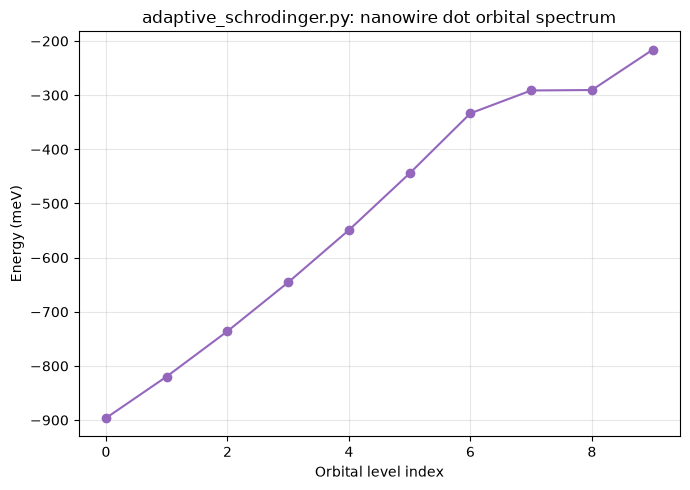

In [21]:
# [실험] 나노와이어 양자점 10-level 궤도 스펙트럼
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(levels_nw_df["level"], levels_nw_df["energy_eV"] * 1e3, "o-", color="C4")
ax.set_xlabel("Orbital level index")
ax.set_ylabel("Energy (meV)")
ax.set_title("adaptive_schrodinger.py: nanowire dot orbital spectrum")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "cell36_figure.png", dpi=150)
plt.show()

**해석:** 준위 간격(`gap_to_next`)이 대체로 0.08-0.11 eV(80-110 meV)로
일정한 편이다가, 7-8번째 준위 부근에서 간격이 급격히 좁아진다(약
0.0008-0.079 eV) — 이는 서로 다른 양자화 방향(예: 길이방향 vs 단면
방향 confinement)에서 오는 준위가 겹치기 시작하거나, 원통형 나노와이어
단면의 각운동량 축퇴가 깨지면서 생기는 준-축퇴 준위 쌍으로 해석할 수
있다. `creating_dot.py`(GaAs lead-dot-lead)와는 전혀 다른 소자
형상이므로 절대 에너지 값을 직접 비교하는 것은 의미가 없다 — 둘 다
band-edge 기준 상대 에너지이지만 기준점이 되는 band-edge 자체가
다르다.

In [22]:
# [점검] 총 실행 시간 중 실제 계산 대비 오버헤드 비율
timestamp_events = [float(t) for t in re.findall(r"\((\d+\.\d+)s\)\s*\[", adaptive_schrod_log)]
total_time_as = float(re.search(r"Total simulation time: ([\d.]+) s", adaptive_schrod_log).group(1))
poisson_refined_summary = re.search(
    r"Error converged below required tolerance after:\s*\n>\s*(\d+) Poisson iterations\.\s*\n>\s*([\d.]+) s\.",
    adaptive_schrod_log,
)
refined_stage_time_as = float(poisson_refined_summary.group(2))

if len(timestamp_events) >= 2:
    gaps = np.diff(timestamp_events)
    max_gap = gaps.max()
    max_gap_idx = int(np.argmax(gaps))
    print(f"Diagnostic-message timestamps found: {len(timestamp_events)}")
    print(f"Largest gap between consecutive diagnostic messages: {max_gap:.1f} s "
          f"(between message #{max_gap_idx+1} and #{max_gap_idx+2})")

accounted_time = refined_stage_time_as + poisson_as_df.loc[coarse_mask_as, "time_s"].sum() + schrod_time_as
print(f"\nTotal logged simulation time      : {total_time_as:.1f} s")
print(f"Sum of itemized solve stages       : {accounted_time:.1f} s "
      f"(coarse Poisson + refined Poisson + Schrodinger)")
print(f"Unaccounted overhead                : {total_time_as - accounted_time:.1f} s "
      f"({(total_time_as - accounted_time) / total_time_as:.0%} of total)")

Diagnostic-message timestamps found: 10
Largest gap between consecutive diagnostic messages: 353.1 s (between message #3 and #4)

Total logged simulation time      : 2962.4 s
Sum of itemized solve stages       : 333.7 s (coarse Poisson + refined Poisson + Schrodinger)
Unaccounted overhead                : 2628.7 s (89% of total)


**해석:** 로그에 itemize된 solve 단계(coarse Poisson + refined Poisson +
Schrodinger)의 합은 총 실행 시간의 일부에 불과하고, 나머지는 mesh
interpolation, submesh 생성, 그리고 무엇보다 `analysis.plot_bands` /
`submesh.show()` / `analysis.plot_slices` 등 대화형 플롯 호출이 차지하는
시간으로 추정된다. 실제로 `vtkmSlice` 진단 메시지들 사이에 수 분
단위의 공백이 있는데, 이는 슬라이스 플롯 창이 화면에 떠 있는 동안
스크립트 실행이 멈춰 있었음을 시사한다. **실무 시사점**: 배치로
여러 시뮬레이션을 돌릴 때는 `plt.show()`를 인터랙티브 백엔드로 그대로
두면 사람이 창을 닫을 때까지 대기하므로, 자동화된 실행에서는 백엔드를
`Agg`로 강제하거나 `plt.savefig()`로 대체하는 것이 총 소요 시간을
크게 줄이는 방법이다.

## 7. 최종 요약

In [23]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M02 SCHRODINGER — REFERENCE RESULT ANALYSIS SUMMARY")
print("=" * 88)
print(f"[creating_dot.py] Dot submesh: {submesh_nodes:,} nodes, solved in {solve_time_s:.1f} s")
print(f"[creating_dot.py] Energy levels (meV): {np.round(energies_dot_eV * 1e3, 3)}")
print(f"[creating_dot.py] E1-E0 gap: {gap01_eV*1e3:.4f} meV = {gap01_eV*1e6:.1f} ueV "
      f"(>> kT at 10-100 mK -> orbital ground state well isolated)")
print(f"[creating_dot.py] psi0/psi1 centroid <x>: "
      f"{moments_psi0['mean_x_nm']:.2f} / {moments_psi1['mean_x_nm']:.2f} nm (dot region: 50-250 nm)")
print(f"[creating_dot.py] Normalized <psi0|psi1> overlap: {normalized_overlap:.2e} (orthogonality check)")
print(f"[creating_dot.py] HO confinement length sanity check (numeric/analytic sigma ratio): "
      f"y={ho_compare_df['ratio_numeric_over_analytic'].iloc[0]:.2f}, "
      f"z={ho_compare_df['ratio_numeric_over_analytic'].iloc[1]:.2f}")
print(f"[adaptive_schrodinger.py] Mesh nodes: {node_counts_as[0]} -> {node_counts_as[1]}")
print(f"[adaptive_schrodinger.py] 10 orbital levels spanning "
      f"{(energies_nw_eV.max()-energies_nw_eV.min())*1e3:.1f} meV")
print(f"[adaptive_schrodinger.py] Logged solve stages account for only "
      f"{accounted_time/total_time_as:.0%} of total {total_time_as:.0f} s run "
      f"(rest: interactive plotting / mesh interpolation overhead)")
print("=" * 88)

QTCAD M02 SCHRODINGER — REFERENCE RESULT ANALYSIS SUMMARY
[creating_dot.py] Dot submesh: 66,400 nodes, solved in 342.5 s
[creating_dot.py] Energy levels (meV): [-0.191  0.185  0.735]
[creating_dot.py] E1-E0 gap: 0.3759 meV = 375.9 ueV (>> kT at 10-100 mK -> orbital ground state well isolated)
[creating_dot.py] psi0/psi1 centroid <x>: 150.00 / 149.99 nm (dot region: 50-250 nm)
[creating_dot.py] Normalized <psi0|psi1> overlap: 3.81e-07 (orthogonality check)
[creating_dot.py] HO confinement length sanity check (numeric/analytic sigma ratio): y=1.10, z=1.09
[adaptive_schrodinger.py] Mesh nodes: 865 -> 34655
[adaptive_schrodinger.py] 10 orbital levels spanning 680.1 meV
[adaptive_schrodinger.py] Logged solve stages account for only 11% of total 2962 s run (rest: interactive plotting / mesh interpolation overhead)


## 해석 주의사항

- `output/creating_dot_V.vtu`의 `data` 배열은 `d.V` (전자의 confinement
  potential energy, 단위 J)이며, 이 노트북에서는 `/e`로 나누어 eV로
  표시합니다. `output/creating_dot_psi0.vtu`, `psi1.vtu`의 `data`는
  고유함수 **진폭**(임의 정규화)이지 확률밀도가 아닙니다 — 확률밀도는
  `|psi|^2`을 취해야 합니다.
- VTU 파일의 좌표는 nm 단위로 저장되어 있으나, QTCAD 내부 mesh
  (`glob_nodes`)는 SI 단위인 미터를 사용합니다. 두 좌표계를 혼용하지
  않도록 주의해야 합니다.
- z=0, y=0 평면 색상 지도는 `pyvista.slice()`로 잘라낸 뒤 `scipy.griddata`
  로 규칙 격자에 보간한 시각화용 결과이며, mesh 절점 값을 그대로 나타낸
  것이 아닙니다 (선형 보간 오차가 있을 수 있음).
- 5절의 부피 적분 기반 기대값(`<x>`, `sigma_x` 등)은 고유함수의 절대
  정규화(norm)에 의존하지 않는 **비율**로 계산했으므로, `io.save`가 저장한
  임의의 정규화 스케일과 무관하게 유효합니다.
- 5절의 조화진동자 해석해 비교는 x 방향 barrier와의 결합, dot 영역의
  유한 크기 등을 무시한 1D 근사이므로, 정확한 예측이 아니라 오더-오브-
  매그니튜드 수준의 sanity check로만 사용해야 합니다.
- `creating_dot.py`(GaAs lead-dot-lead)와 `adaptive_schrodinger.py`
  (Si 나노와이어 게이트 소자)는 서로 다른 소자 구조이므로, 두 결과의
  절대 에너지 값이나 준위 간격을 직접 비교하는 것은 의미가 없습니다 —
  각각 자신의 band-edge 기준으로 해석해야 합니다.
- `adaptive_schrodinger.py`의 "총 실행 시간 대비 오버헤드" 분석은 로그에
  남은 timestamp 간격으로부터의 **추정**이며, 정확한 프로파일링 결과가
  아닙니다.